<a href="https://colab.research.google.com/github/Madhavan777/DAA-Exp-1/blob/main/DAA_Ex_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated 1000 sorted student roll numbers in range [1, 10000].
Sample: [7, 10, 19, 28, 36, 43, 44, 54, 59, 91] ... [9933, 9934, 9939, 9940, 9950, 9976, 9978, 9981, 9989, 10000]

INDIVIDUAL SEARCH COMPARISON
+----------+-----------+---------------+----------------------+
| Roll No. | Status    | Binary Probes | Interpolation Probes |
+----------+-----------+---------------+----------------------+
| 6623     | Found     | 10            | 3                    |
| 7137     | Found     | 10            | 4                    |
| 9460     | Found     | 10            | 4                    |
| 3120     | Found     | 10            | 3                    |
| 2443     | Found     | 10            | 3                    |
| 1481     | Not found | 10            | 2                    |
| 7111     | Not found | 10            | 3                    |
| 1647     | Not found | 10            | 2                    |
+----------+-----------+---------------+----------------------+

+--------------+-------

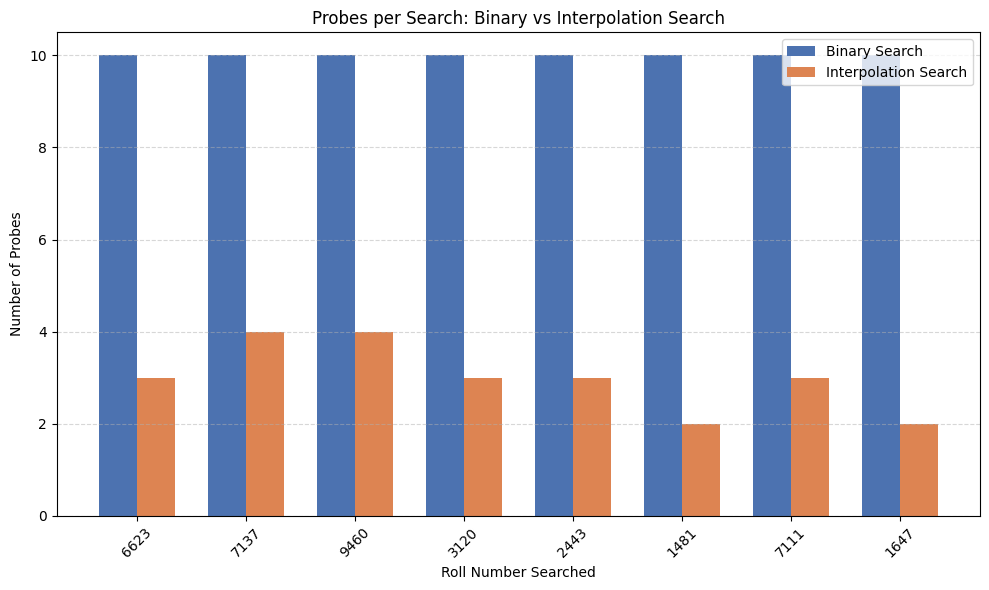

Saved bar chart -> individual_probes_bar.png


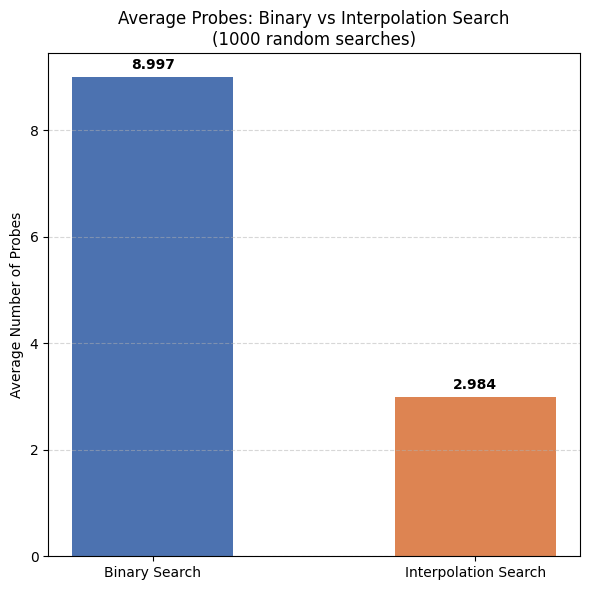

Saved bar chart -> average_probes_bar.png


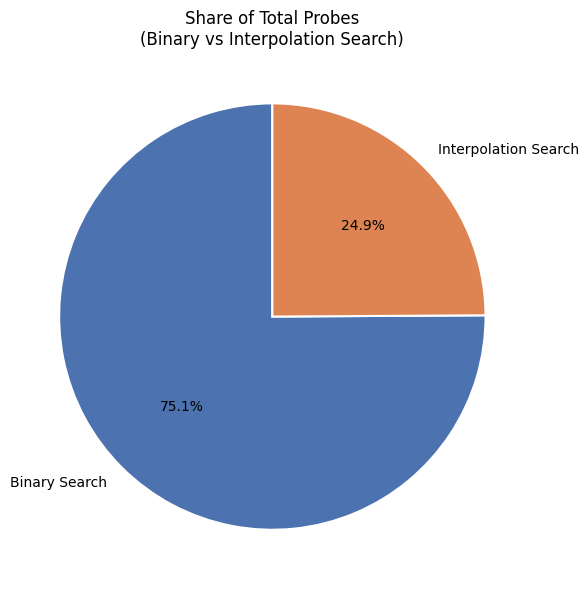

Saved pie chart -> probe_share_pie.png

Conclusion:
Interpolation Search typically needs fewer probes than Binary Search
when data is uniformly distributed, since it estimates the likely
position of the key instead of always checking the middle element.
Binary Search guarantees O(log n) worst case, while Interpolation
Search averages around O(log log n) for uniform data but can degrade
toward O(n) for skewed/non-uniform distributions.


In [5]:
"""
Interpolation Search vs Binary Search
Sorted array of student roll numbers (range 1 to 10000)
Counts the number of probes (comparisons) required by each algorithm.
"""

import random
import matplotlib.pyplot as plt
import numpy as np


def generate_roll_numbers(count=1000, low=1, high=10000):
    """Generate a sorted array of unique student roll numbers."""
    roll_numbers = random.sample(range(low, high + 1), count)
    roll_numbers.sort()
    return roll_numbers


def binary_search(arr, key):
    """Standard binary search. Returns (index, probes)."""
    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high:
        probes += 1
        mid = (low + high) // 2

        if arr[mid] == key:
            return mid, probes
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1, probes


def interpolation_search(arr, key):
    """Interpolation search. Returns (index, probes)."""
    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= key <= arr[high]:
        probes += 1

        if arr[low] == arr[high]:
            if arr[low] == key:
                return low, probes
            else:
                break

        # Interpolation formula estimates the likely position of key
        pos = low + ((key - arr[low]) * (high - low)) // (arr[high] - arr[low])

        if arr[pos] == key:
            return pos, probes
        elif arr[pos] < key:
            low = pos + 1
        else:
            high = pos - 1

    return -1, probes


def compare_search(arr, key):
    """Run both searches on a single key and return a result row."""
    bin_idx, bin_probes = binary_search(arr, key)
    interp_idx, interp_probes = interpolation_search(arr, key)

    status = "Found" if bin_idx != -1 else "Not found"

    return {
        "roll_no": key,
        "status": status,
        "bin_probes": bin_probes,
        "interp_probes": interp_probes,
    }


def print_table(headers, rows):
    """Print a list of equal-length row tuples as a clean ASCII table."""
    col_widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            col_widths[i] = max(col_widths[i], len(str(cell)))

    def format_row(row):
        return "| " + " | ".join(
            str(cell).ljust(col_widths[i]) for i, cell in enumerate(row)
        ) + " |"

    separator = "+-" + "-+-".join("-" * w for w in col_widths) + "-+"

    print(separator)
    print(format_row(headers))
    print(separator)
    for row in rows:
        print(format_row(row))
    print(separator)


def plot_individual_comparison(results, save_path="individual_probes_bar.png"):
    """Grouped bar chart: probes per roll number for each algorithm."""
    labels = [str(r["roll_no"]) for r in results]
    bin_probes = [r["bin_probes"] for r in results]
    interp_probes = [r["interp_probes"] for r in results]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width / 2, bin_probes, width, label="Binary Search", color="#4C72B0")
    ax.bar(x + width / 2, interp_probes, width, label="Interpolation Search", color="#DD8452")

    ax.set_xlabel("Roll Number Searched")
    ax.set_ylabel("Number of Probes")
    ax.set_title("Probes per Search: Binary vs Interpolation Search")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved bar chart -> {save_path}")


def plot_average_bar(avg_bin, avg_interp, save_path="average_probes_bar.png"):
    """Simple bar chart comparing average probes."""
    labels = ["Binary Search", "Interpolation Search"]
    values = [avg_bin, avg_interp]
    colors = ["#4C72B0", "#DD8452"]

    fig, ax = plt.subplots(figsize=(6, 6))
    bars = ax.bar(labels, values, color=colors, width=0.5)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_ylabel("Average Number of Probes")
    ax.set_title("Average Probes: Binary vs Interpolation Search\n(1000 random searches)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved bar chart -> {save_path}")


def plot_probe_share_pie(avg_bin, avg_interp, save_path="probe_share_pie.png"):
    """Pie chart showing each algorithm's share of total probes used."""
    labels = ["Binary Search", "Interpolation Search"]
    values = [avg_bin, avg_interp]
    colors = ["#4C72B0", "#DD8452"]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        values,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    ax.set_title("Share of Total Probes\n(Binary vs Interpolation Search)")
    ax.axis("equal")

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved pie chart -> {save_path}")


def main():
    random.seed(42)  # reproducible results
    n = 1000
    roll_numbers = generate_roll_numbers(count=n, low=1, high=10000)

    print(f"Generated {n} sorted student roll numbers in range [1, 10000].")
    print(f"Sample: {roll_numbers[:10]} ... {roll_numbers[-10:]}\n")

    # Pick some roll numbers to search: existing ones + a few that don't exist
    existing_samples = random.sample(roll_numbers, 5)
    missing_samples = []
    while len(missing_samples) < 3:
        candidate = random.randint(1, 10000)
        if candidate not in roll_numbers:
            missing_samples.append(candidate)

    test_keys = existing_samples + missing_samples

    print("INDIVIDUAL SEARCH COMPARISON")
    results = [compare_search(roll_numbers, key) for key in test_keys]

    table_rows = [
        (r["roll_no"], r["status"], r["bin_probes"], r["interp_probes"])
        for r in results
    ]
    print_table(
        ["Roll No.", "Status", "Binary Probes", "Interpolation Probes"],
        table_rows,
    )

    total_bin_probes = sum(r["bin_probes"] for r in results)
    total_interp_probes = sum(r["interp_probes"] for r in results)

    print()
    print_table(
        ["Metric", "Binary Search", "Interpolation Search"],
        [("Total probes", total_bin_probes, total_interp_probes)],
    )

    # Large-scale average comparison over many random existing keys
    trials = 1000
    bin_total, interp_total = 0, 0

    for _ in range(trials):
        key = random.choice(roll_numbers)
        _, bp = binary_search(roll_numbers, key)
        _, ip = interpolation_search(roll_numbers, key)
        bin_total += bp
        interp_total += ip

    avg_bin = round(bin_total / trials, 3)
    avg_interp = round(interp_total / trials, 3)

    print(f"\nAVERAGE PROBE COMPARISON ({trials} random searches)")
    print_table(
        ["Metric", "Binary Search", "Interpolation Search"],
        [("Average probes", avg_bin, avg_interp)],
    )

    # ---- Charts ----
    plot_individual_comparison(results)
    plot_average_bar(avg_bin, avg_interp)
    plot_probe_share_pie(avg_bin, avg_interp)

    print("\nConclusion:")
    print("Interpolation Search typically needs fewer probes than Binary Search")
    print("when data is uniformly distributed, since it estimates the likely")
    print("position of the key instead of always checking the middle element.")
    print("Binary Search guarantees O(log n) worst case, while Interpolation")
    print("Search averages around O(log log n) for uniform data but can degrade")
    print("toward O(n) for skewed/non-uniform distributions.")


if __name__ == "__main__":
    main()